# Analysis of Adult Income Dataset

## 1. Importing the Data

The data is imported from https://www.kaggle.com/datasets/wenruliu/adult-income-dataset. The objective of this analysis is to develop a predictive model that can accurately categorize if an individual's annual income is greater than $50,000. This will be done by considering factors such as age, education, workclass, occupation, and others. This entails employing a range of machine learning methods, including as Logistic Regression, K-Nearest Neighbors, Gaussian Naive Bayes, and others, to ascertain the most accurate predictor of income level. Additionally, preprocessing measures, such as addressing missing data and encoding categorical variables, are implemented.


In [1]:
from IPython.display import HTML

HTML('''
<script>
code_show = true;
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
}
$( document ).ready(code_toggle);
</script>

<form action="javascript:code_toggle()">
<input type="submit" value="Show/Hide Code">
</form>
''')

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder()
import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFE

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")
income = pd.read_csv('/Users/tramanhho/Documents/COMP2200/adult.csv')
income.shape

(48842, 15)

There are 48842 observations and 15 different features in this dataset.

## 2. Exploring Data

In [2]:
income.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
income.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [4]:
# Checking for missing values
income.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [5]:
income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [6]:
income.isin(['?']).sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [7]:
income.age = income.age.astype(float)
income['hours-per-week'] = income['hours-per-week'].astype(float)

In [8]:
# Attributes workclass, occupation, and native-country have '?' which is considered NA values
# Replace '?' with nan value
income['workclass'] = income['workclass'].replace('?',np.nan)
income['occupation'] = income['occupation'].replace('?',np.nan)
income['native-country'] = income['native-country'].replace('?',np.nan)


In [9]:
# Remove nan value
income.dropna(how='any',inplace=True)
income
income.isin(['?']).sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [10]:
income.shape

(45222, 15)

In [11]:
income = income.drop_duplicates()

In [12]:
income.shape

(45175, 15)

In [13]:
print('workclass',income.workclass.unique())
print('education',income.education.unique())
print('educational-num',income['educational-num'].unique())
print('marital-status',income['marital-status'].unique())
print('occupation',income.occupation.unique())
print('relationship',income.relationship.unique())
print('race',income.race.unique())
print('gender',income.gender.unique())
print('native-country',income['native-country'].unique())


workclass ['Private' 'Local-gov' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay']
education ['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' '5th-6th' 'Assoc-voc' '9th' 'Doctorate'
 '12th' '1st-4th' 'Preschool']
educational-num [ 7  9 12 10  6 15  4 13 14  3 11  5 16  8  2  1]
marital-status ['Never-married' 'Married-civ-spouse' 'Widowed' 'Separated' 'Divorced'
 'Married-spouse-absent' 'Married-AF-spouse']
occupation ['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' 'Other-service'
 'Prof-specialty' 'Craft-repair' 'Adm-clerical' 'Exec-managerial'
 'Tech-support' 'Sales' 'Priv-house-serv' 'Transport-moving'
 'Handlers-cleaners' 'Armed-Forces']
relationship ['Own-child' 'Husband' 'Not-in-family' 'Unmarried' 'Wife' 'Other-relative']
race ['Black' 'White' 'Other' 'Amer-Indian-Eskimo' 'Asian-Pac-Islander']
gender ['Male' 'Female']
native-country ['United-States' 'Peru' 'Guatemala' 'Mexico' 'Dominican-Republ

As observed from the results, education and education-num has similar value. `education` has string while `education-num` has numerical values.

HS-grad from education represents 9 in education-num

Masters from education represents 14 in education-num and likewise.

Both columns conveying same information

So, we can remove 'education-num' column

## 3. Data Visualisation

Text(0.5, 1.0, 'Histogram')

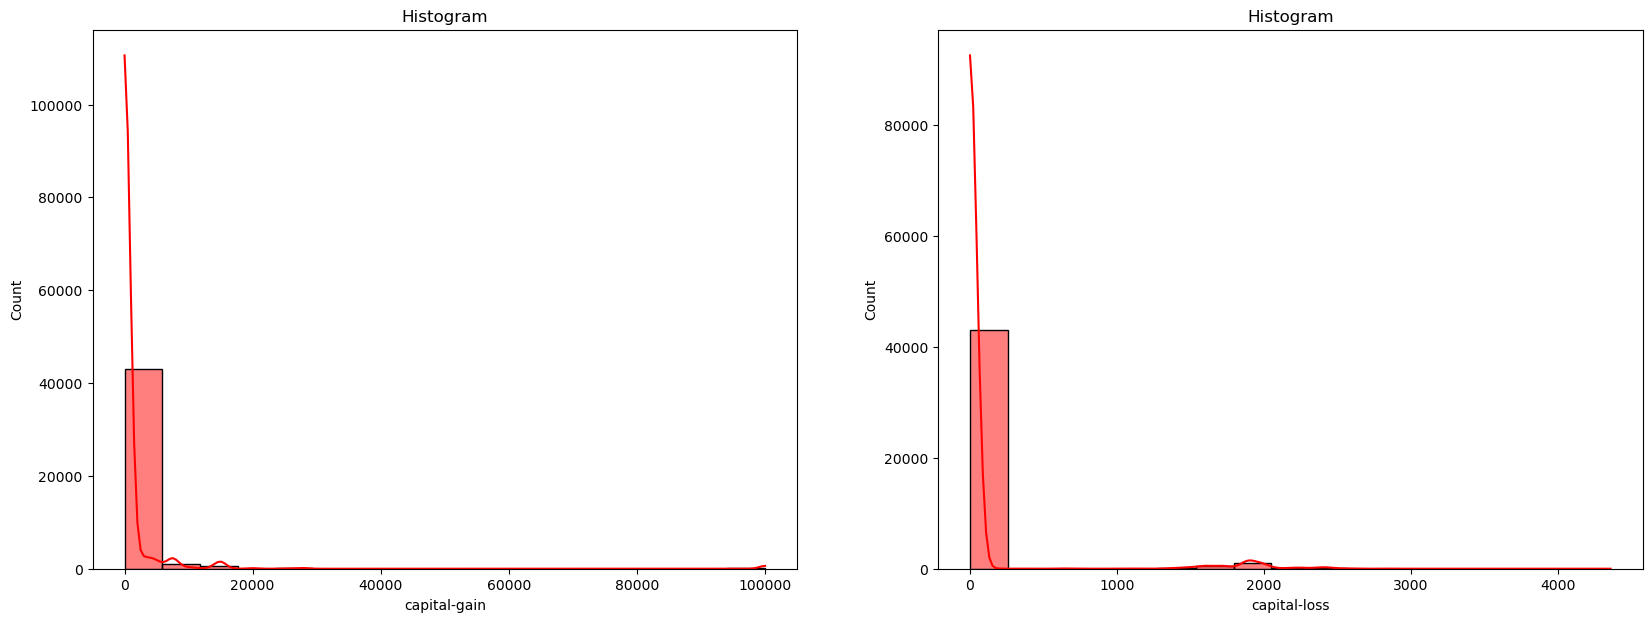

In [14]:
plt.figure(figsize=(20, 7))
plt.subplot(1, 2, 1)
sns.histplot(income['capital-gain'], kde = True,color='r')
plt.title('Histogram')
plt.subplot(1, 2, 2)
sns.histplot(income['capital-loss'], kde = True,color='r')
plt.title('Histogram')

`capital-gain` and `capital-loss` both columns have 75% data is 0.00. Therefore, we can drop `capital-gain` and `capital-loss`. 

In [15]:
income_1 = income.drop(['educational-num', 'capital-gain', 'capital-loss'], axis=1)
income_1.head()

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,income
0,25.0,Private,226802,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,40.0,United-States,<=50K
1,38.0,Private,89814,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,50.0,United-States,<=50K
2,28.0,Local-gov,336951,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,40.0,United-States,>50K
3,44.0,Private,160323,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,40.0,United-States,>50K
5,34.0,Private,198693,10th,Never-married,Other-service,Not-in-family,White,Male,30.0,United-States,<=50K


In [16]:
income_1.shape

(45175, 12)

### Univariate Analysis

#### Education

<Axes: xlabel='count', ylabel='education'>

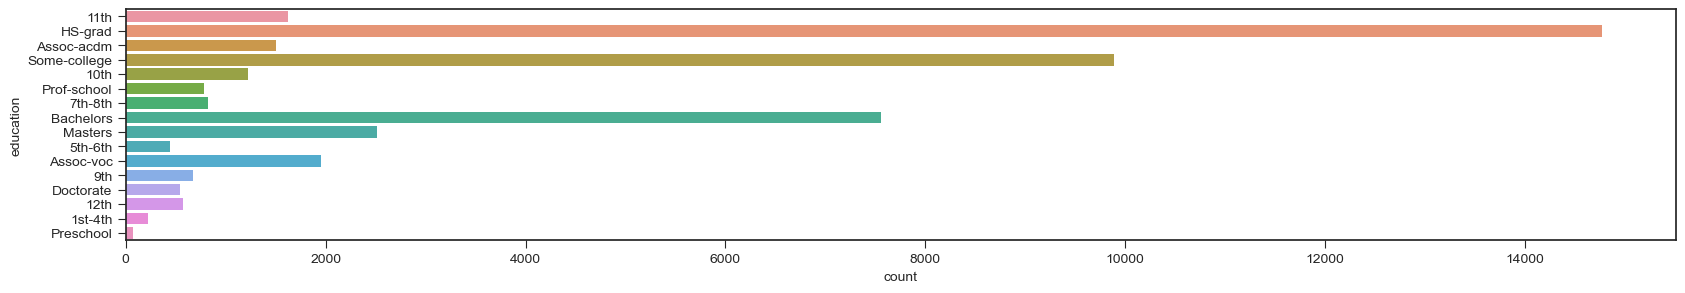

In [17]:
fig = plt.figure(figsize=(20,3))
plt.style.use('seaborn-ticks')
sns.countplot(y = "education", data = income_1)

HS-grad accounts for the highest number while advanced degrees such as Master's, PhDs, and professional schooling (referred to as "Prof-school") are not as prevalent.

#### Marital Status

<Axes: xlabel='count', ylabel='marital-status'>

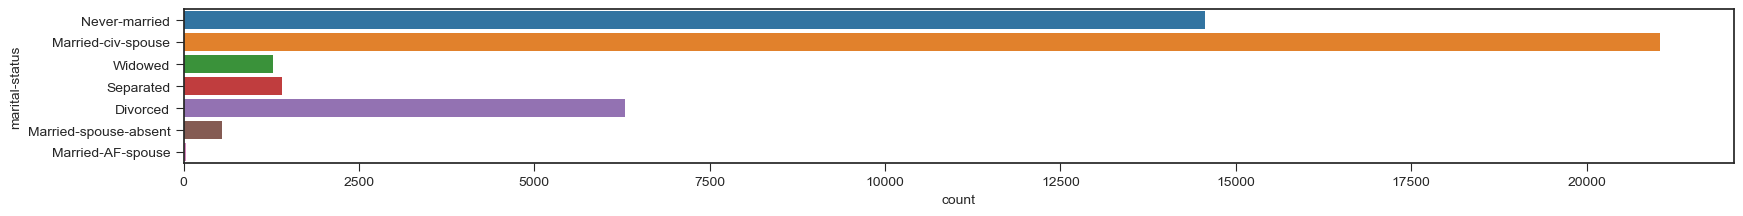

In [18]:
fig = plt.figure(figsize=(20,2))
plt.style.use('seaborn-ticks')
sns.countplot(y="marital-status", data = income_1)

The majority of the dataset consists of persons who are married and cohabitating with a spouse, with never-married individuals being the next largest group. Divorced, widowed, and separated individuals constitute lesser portions of the population.

#### Occupation

<Axes: xlabel='count', ylabel='occupation'>

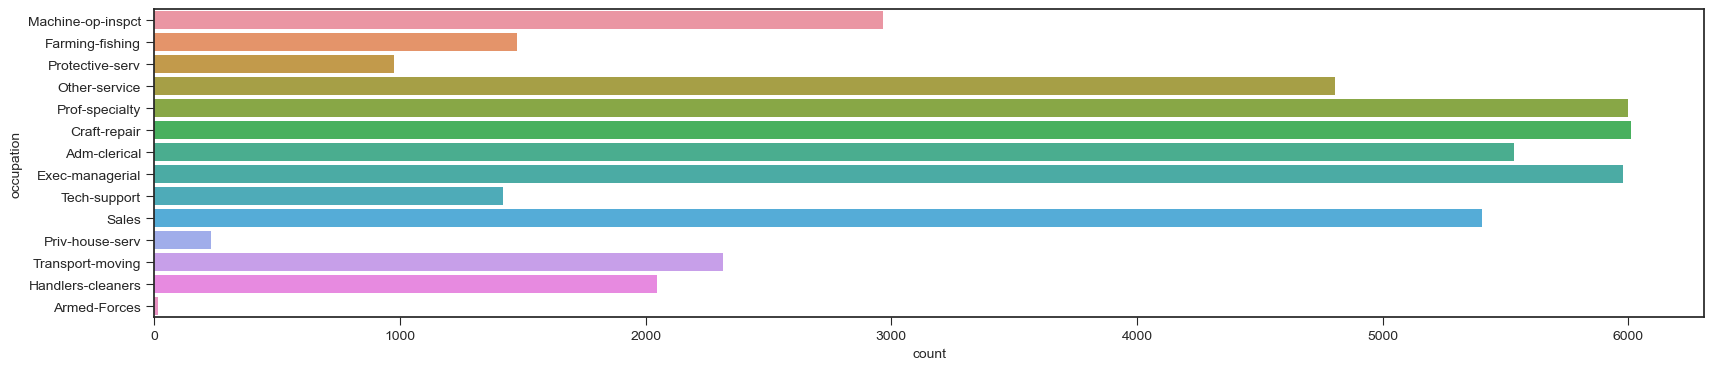

In [19]:
plt.style.use('seaborn-ticks')
plt.figure(figsize=(20,4)) 
sns.countplot(y="occupation", data=income_1)

The predominant jobs are 'Adm-clerical', 'Craft-repair', and 'Prof-specialty', suggesting a varied workforce encompassing administrative positions, skilled trades, and professional expertise. Uncommon jobs such as those in the 'Armed-Forces' and 'Priv-house-serv' categories indicate a smaller number of persons working in these roles within the dataset.

#### Workclass

<Axes: xlabel='count', ylabel='workclass'>

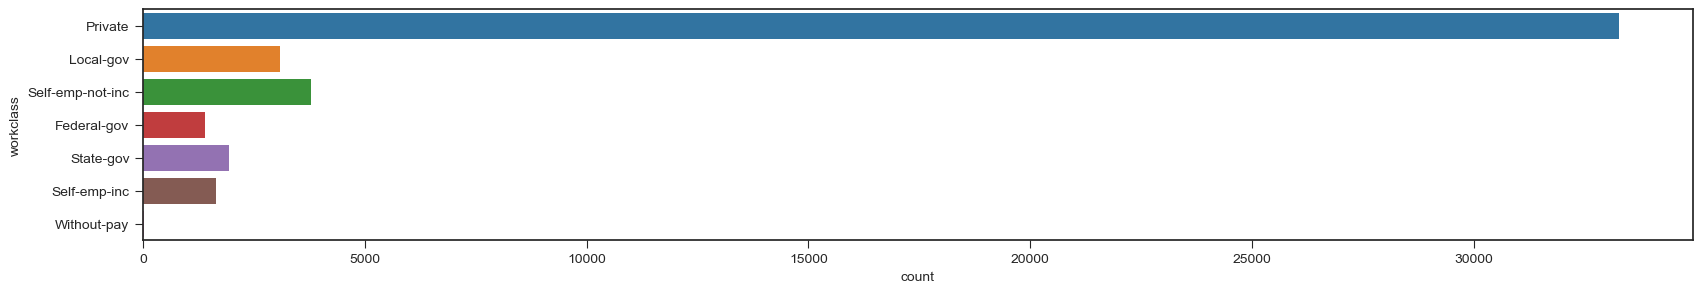

In [20]:
plt.style.use('seaborn-ticks')
plt.figure(figsize=(20,3)) 
sns.countplot(y="workclass", data=income_1)

The 'Private' sector is the predominant work class, far surpassing others in terms of the number of participants. The categories 'Local-gov' and 'Self-emp-not-inc' exhibit limited presence. 

#### Age

In [21]:
# Finding max and min values for Age
max = income_1['age'].max()
min = income_1['age'].min()
print("Max Age is:",max)
print("Min Age is:",min)

Max Age is: 90.0
Min Age is: 17.0


<Axes: xlabel='age', ylabel='Density'>

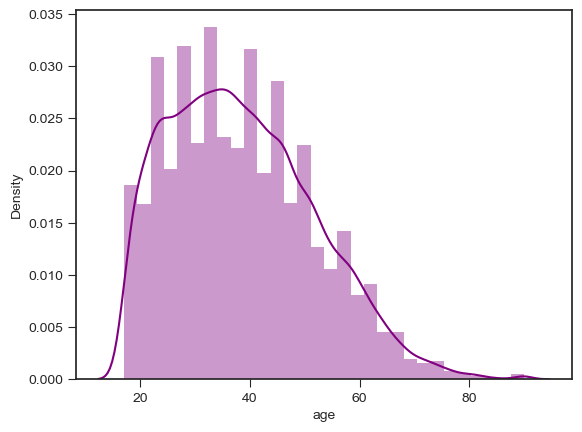

In [22]:
sns.distplot(income_1['age'],bins = 30,color = "purple")

<Axes: >

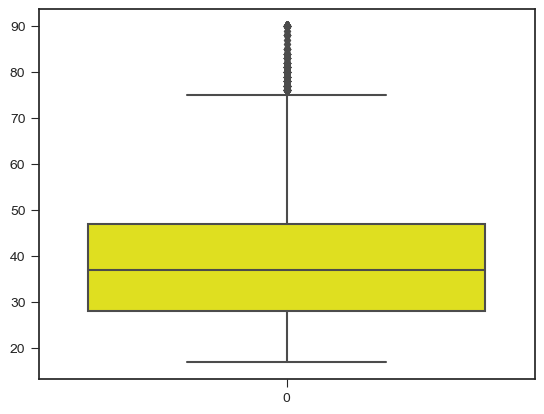

In [23]:
sns.boxplot(income_1['age'],color = "yellow")

The histogram has a bimodal distribution, indicating two unique peaks in the dataset. One peak is shown in the early 20s, while the other is observed in the mid-40s. This suggests the presence of several age groups in the dataset, which may correspond to various periods in a person's career or life cycle. The boxplot displays a median age in the early 40s, with the interquartile range spanning from around 30 to 50 years old, showing that the middle 50% of ages fall within this range. Outliers are seen above the top whisker, indicating the existence of people who are considerably older than the average participant in the sample.

#### Hours per week

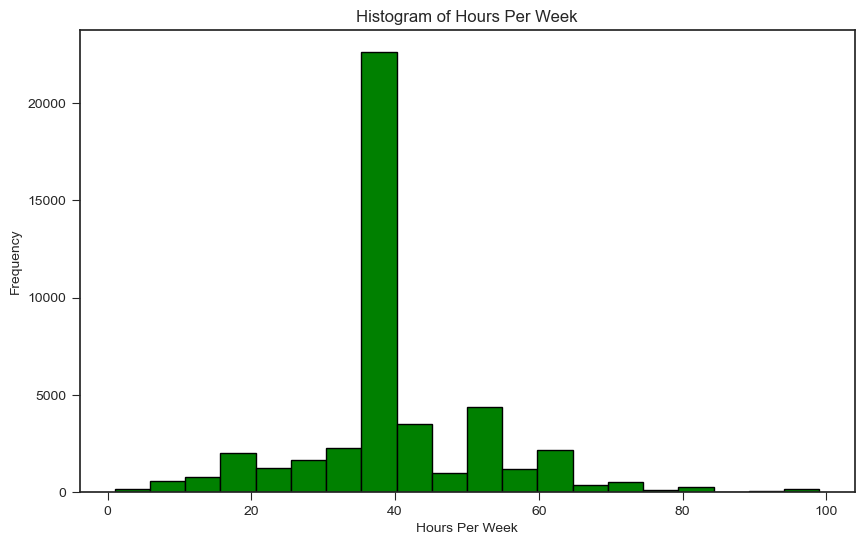

In [24]:
plt.figure(figsize=(10, 6))
plt.hist(income_1['hours-per-week'], bins=20, color='green', edgecolor='black')
plt.title('Histogram of Hours Per Week')
plt.xlabel('Hours Per Week')
plt.ylabel('Frequency')
plt.show()

In this dataset, it is shown that most of people work 40 hours per week and the second highest is approxiamtely 50 hours.

#### Gender

<Axes: ylabel='count'>

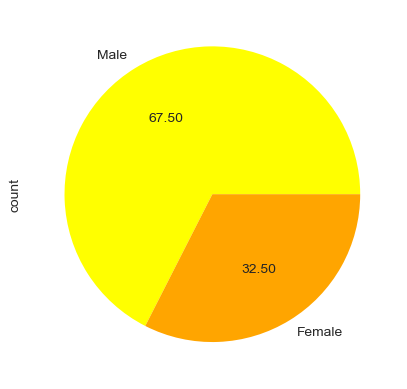

In [25]:
colors = ["yellow","orange"]
income_1["gender"].value_counts().plot(kind="pie",autopct="%.2f",colors=colors)

It is evident that the distribution of genders is relatively equal, with males accounting for a substantially higher proportion at 67.5% compared to females at 32.5%.

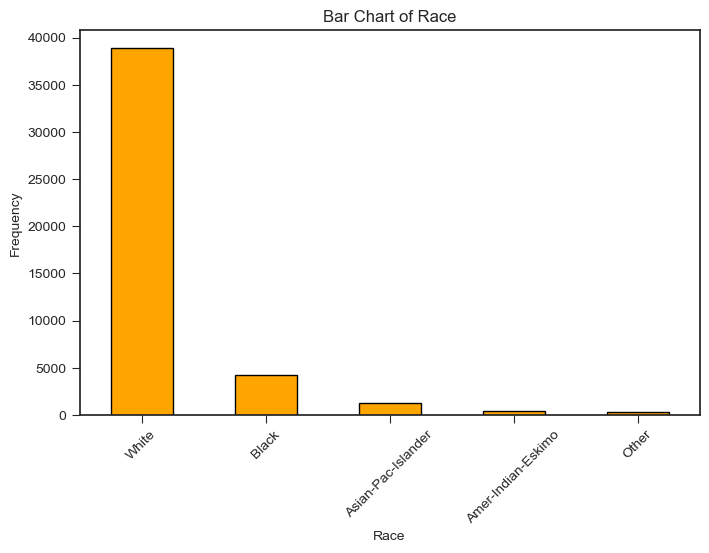

In [26]:
race_counts = income_1['race'].value_counts()
plt.figure(figsize=(8, 5))
race_counts.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Bar Chart of Race')
plt.xlabel('Race')
plt.ylabel('Frequency')
plt.xticks(rotation = 45) 
plt.show()

It is observed that there is a highest number of White distributed in this dataset, which is nearly 40000 and followed by Black and Asian-Pac-Islander

### Bivariate Analysis

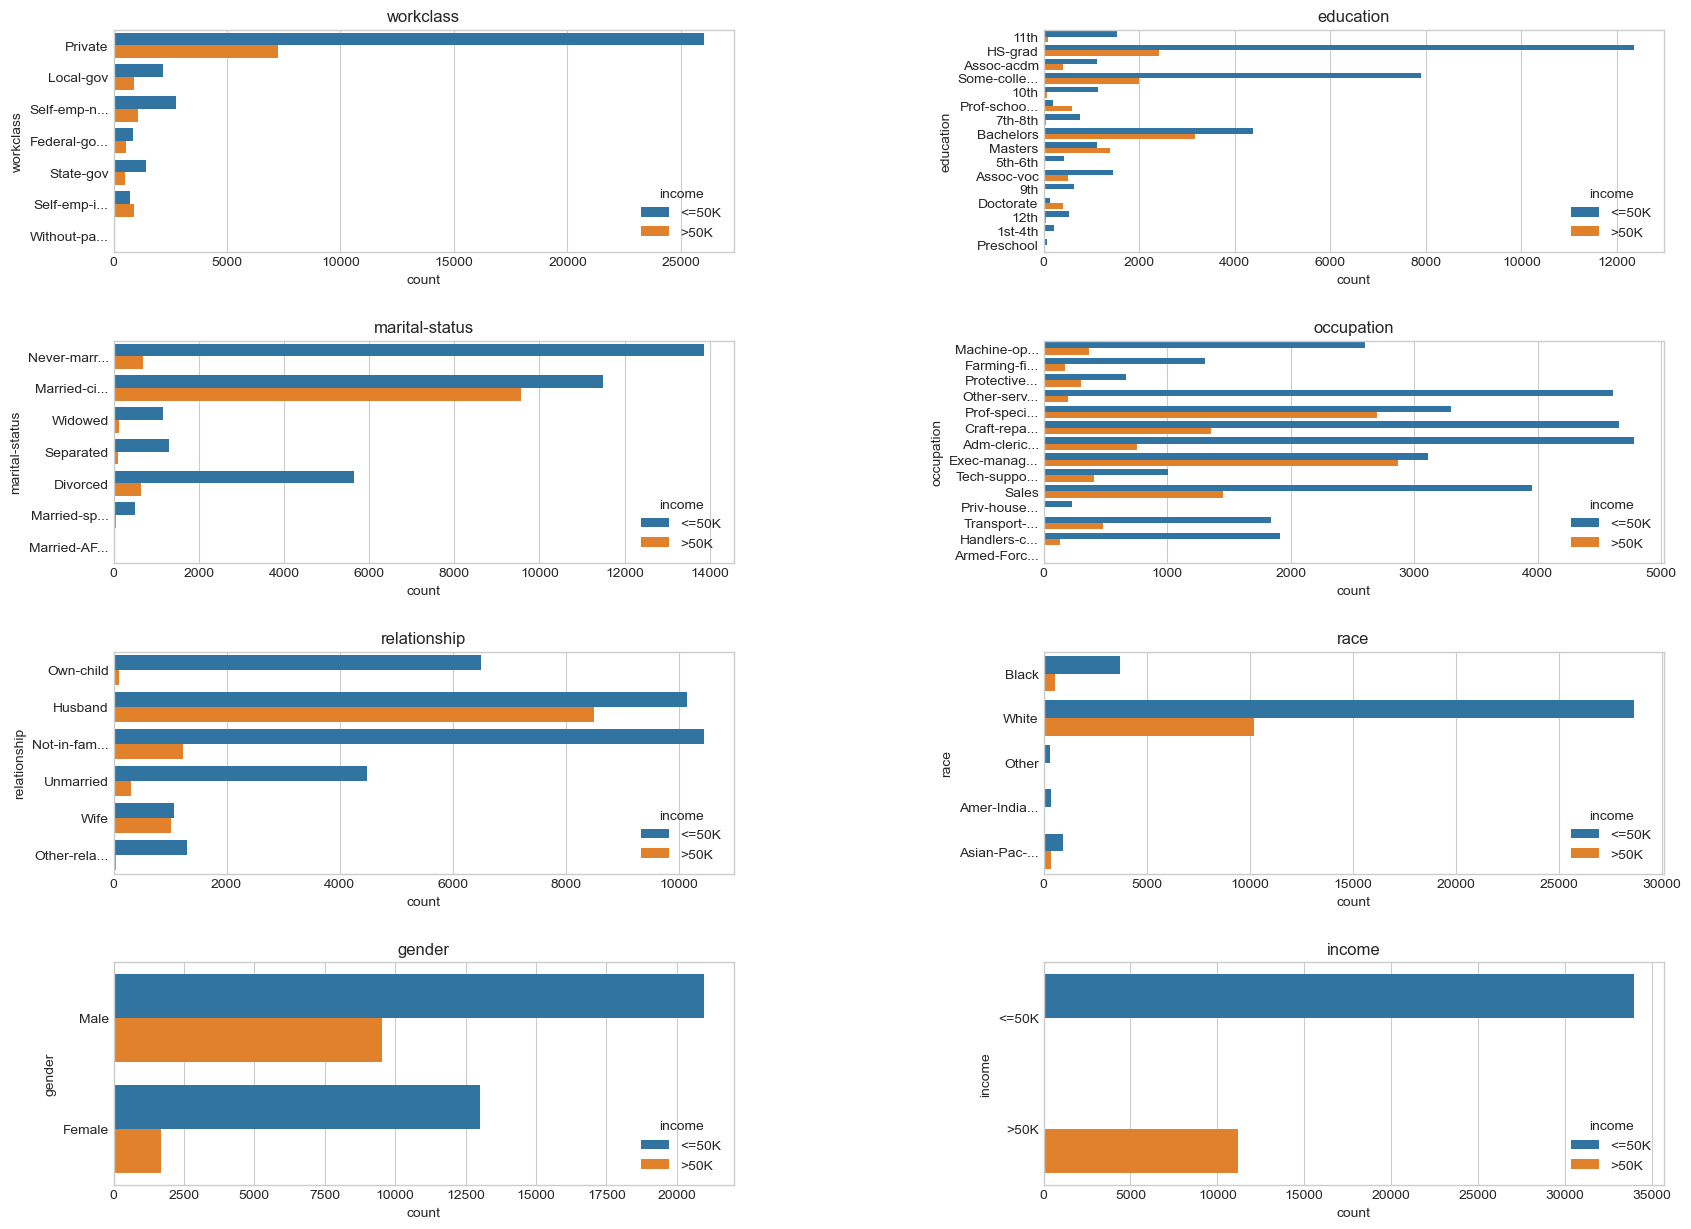

In [27]:

# Assuming my_df is already loaded and available
# Define the columns and the hue for plotting
columns = ['workclass', 'education', 'marital-status', 'occupation', 
           'relationship', 'race', 'gender', 'income']
hue = 'income'

# Filtering the dataset to include only the relevant columns
bivariate_df = income_1.loc[:, columns]

# Filter to include only object type columns for categorical plotting
categorical_data = bivariate_df.select_dtypes(include=['object'])

# Setup plot parameters
cols = 2
width = 20
height = 15
hspace = 0.4
wspace = 0.5

# Calculating number of rows needed for the subplots based on the number of columns
rows = (len(categorical_data.columns) + cols - 1) // cols  # Using integer division to calculate rows

# Create a figure object
plt.style.use('seaborn-whitegrid')
fig = plt.figure(figsize=(width, height))
fig.subplots_adjust(wspace=wspace, hspace=hspace)

# Plotting each categorical column
for i, column in enumerate(categorical_data.columns):
    ax = fig.add_subplot(rows, cols, i + 1)
    ax.set_title(column)
    g = sns.countplot(y=column, hue=hue, data=bivariate_df, ax=ax)
    substrings = [s.get_text()[:10] + '...' if len(s.get_text()) > 10 else s.get_text() for s in g.get_yticklabels()]
    g.set(yticklabels=substrings)

# Show the plot
plt.show()


The 'Private' job class is predominant in all income categories, with higher earners being more evenly distributed among several classes, including 'Self-emp-not-inc', which shows a considerable inclination towards earning more than $50K.

Education and Occupation: There is a substantial correlation between higher levels of education, such as obtaining a Bachelor's or Master's degree, and having an income above $50,000. Likewise, jobs that are professional and technology-focused exhibit a distinct preference for greater incomes, which indicates the significance of further education and specialized abilities in attaining higher income levels.

Marital Status and Relationship: The presence of individuals classified as 'Married-civ-spouse' is notable among the >$50K income category, indicating that being married and the financial advantages of pooling family incomes may have an impact on the likelihood of obtaining a higher salary.

The charts depict income discrepancies across various ethnic groupings and genders, highlighting the dominance of the 'White' and 'Male' categories in the higher income bracket. This suggests the presence of demographic inequalities in wages.


#### Average Age by Occupation vs Income 

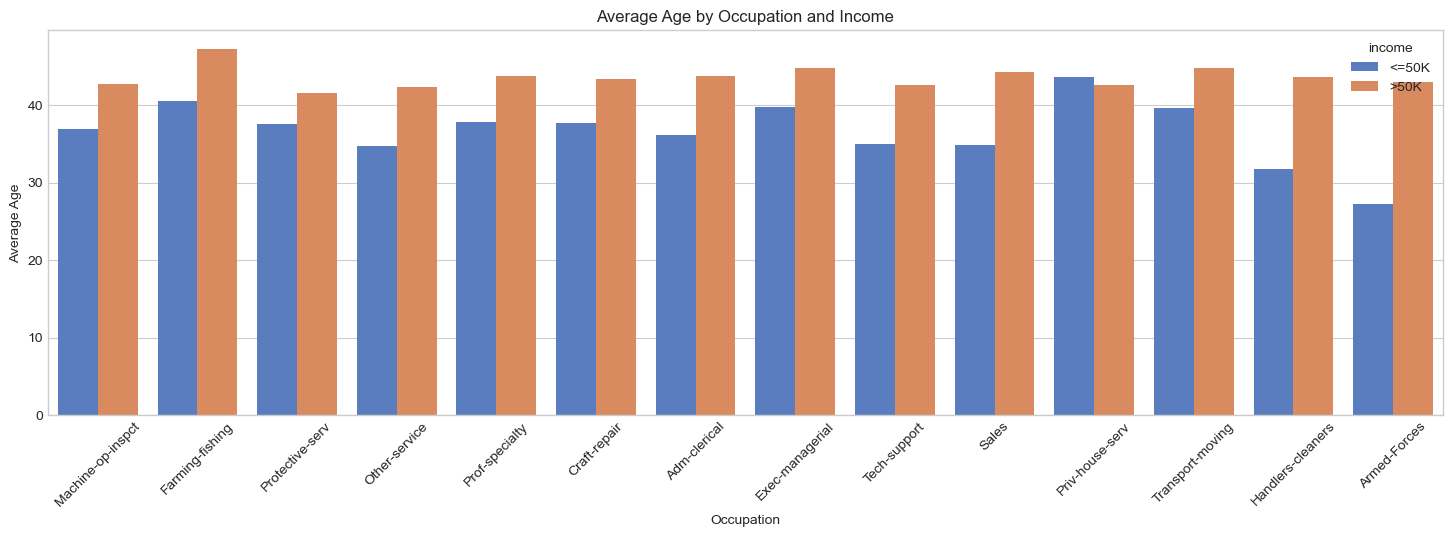

In [28]:
# Set up the dimensions for the plot
plt.figure(figsize=(18, 5))

# Create a bar plot
sns.barplot(x="occupation", y="age", hue="income", data=income_1, palette="muted", ci=None)

# Enhance the plot with labels and title
plt.title('Average Age by Occupation and Income')
plt.xlabel('Occupation')
plt.ylabel('Average Age')
plt.xticks(rotation=45)  # Rotate labels for better readability

# Display the plot
plt.show()

Typically, in most professions, persons who make more than $50K are usually older, indicating that greater income levels are linked to individuals with more experience. Notable deviations from this pattern may be observed in certain professions such as 'Tech-support' and 'Handlers-cleaners', where the disparity in income between different age groups is insignificant. This suggests that variables other than age can play a role in determining income levels in these jobs. 

#### Age by Race vs Income

<Axes: xlabel='race', ylabel='age'>

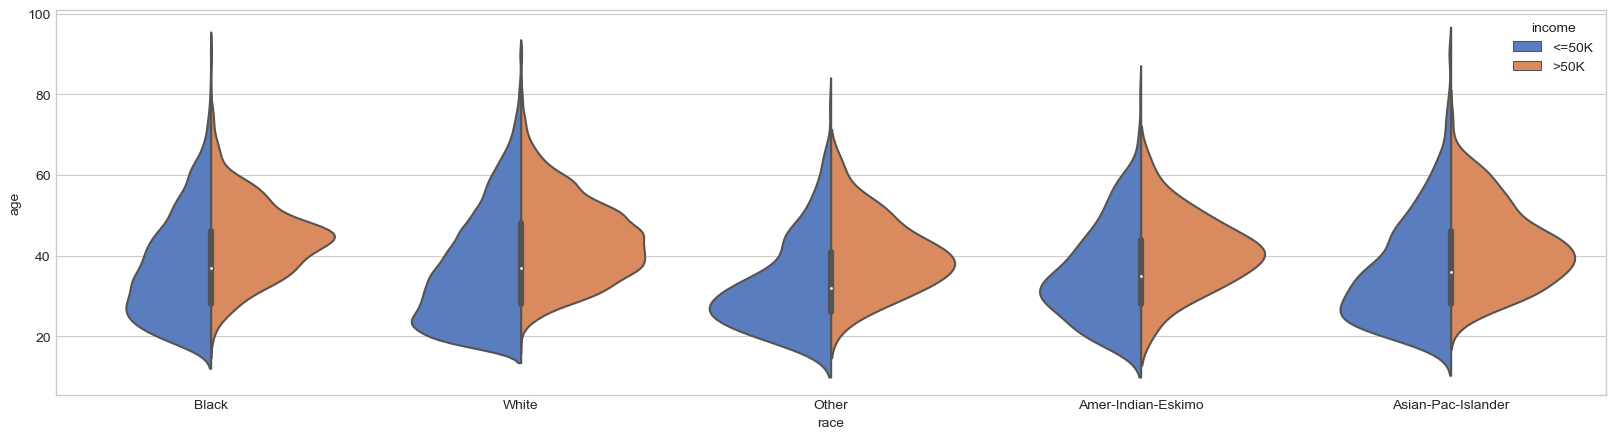

In [29]:
from matplotlib import pyplot
a4_dims = (20, 5)
fig, ax = pyplot.subplots(figsize=a4_dims)
ax = sns.violinplot(x="race", y="age", hue="income",
                    data=income_1, gridsize=100, palette="muted", split=True, saturation=0.75)
ax

The data indicates that there is a correlation between greater wages and older age groups among all racial demographics. The breadth of each violin graphically represents the population density at various age groups, with a noticeably broader portion throughout middle ages, especially for those earning more over 50K annually. The figure reveals notable discrepancies in the age distribution across different income levels within each racial group, indicating that higher income is associated with older age, possibly indicating career progression and gained expertise.

#### Age vs Hours per Week by Gender

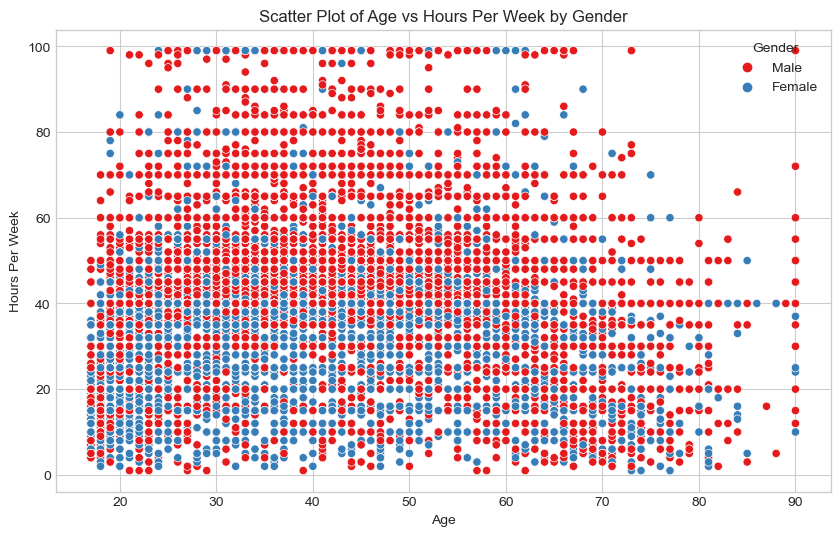

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='hours-per-week', hue='gender', data=income_1, palette='Set1')
plt.title('Scatter Plot of Age vs Hours Per Week by Gender')
plt.xlabel('Age')
plt.ylabel('Hours Per Week')
plt.legend(title='Gender')
plt.show()

The scatter figure illustrates the correlation between age and weekly working hours, categorized by gender, for a given dataset. The distribution indicates that, regardless of gender, the bulk of data points concentrate around the typical 40-hour work week for all age groups. Significantly, the number of females employed for more than 60 hours is lower than that of males, particularly in older age brackets. In general, the plot demonstrates a steady pattern in working hours regardless of age, although gender reveals certain disparities in working extended hours.

### Pair Plot

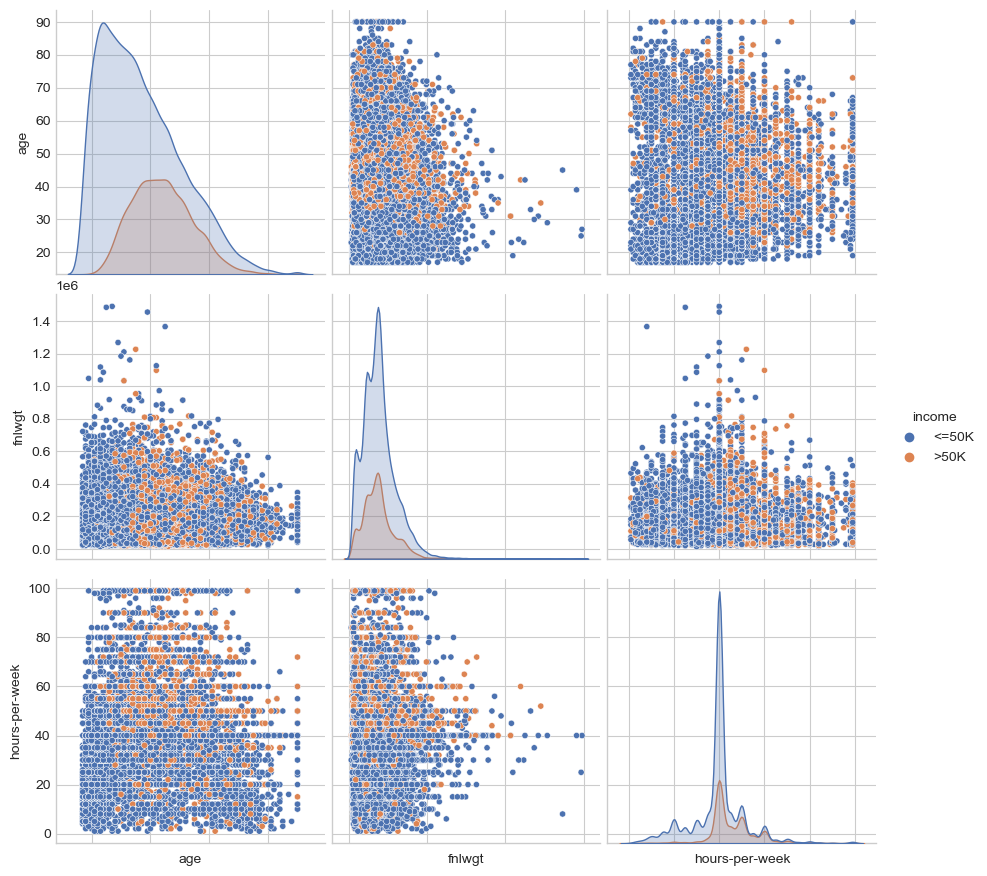

In [31]:
#pair plots of entire dataset
pp = sns.pairplot(income_1, hue = 'income', palette = 'deep', 
                  size=3, diag_kind = 'kde', diag_kws=dict(shade=True), plot_kws=dict(s=20) )
pp.set(xticklabels=[])

The age distribution reveals a predominance of younger persons in the <=50K group, while higher incomes exhibit a wider variety of ages. The data for hours-per-week shows a typical peak at 40 hours for those with lower incomes, but those with higher incomes have a greater range of working hours, indicating unpredictability in their work schedules. The plots depicting the relationship between age, fnlwgt, and hours-per-week reveal no discernible link, particularly with fnlwgt, hence proving its little influence on income. 

In [32]:
# Creating a copy for a dataframe
income_2 = income_1

In [33]:
# Transforming categorical values into numerical value
ord_enc = OrdinalEncoder()
income_2[['gender','workclass','education','marital-status','occupation','relationship','race','native-country','income']] = ord_enc.fit_transform(income_1[['gender','workclass','education','marital-status','occupation','relationship','race','native-country','income']])

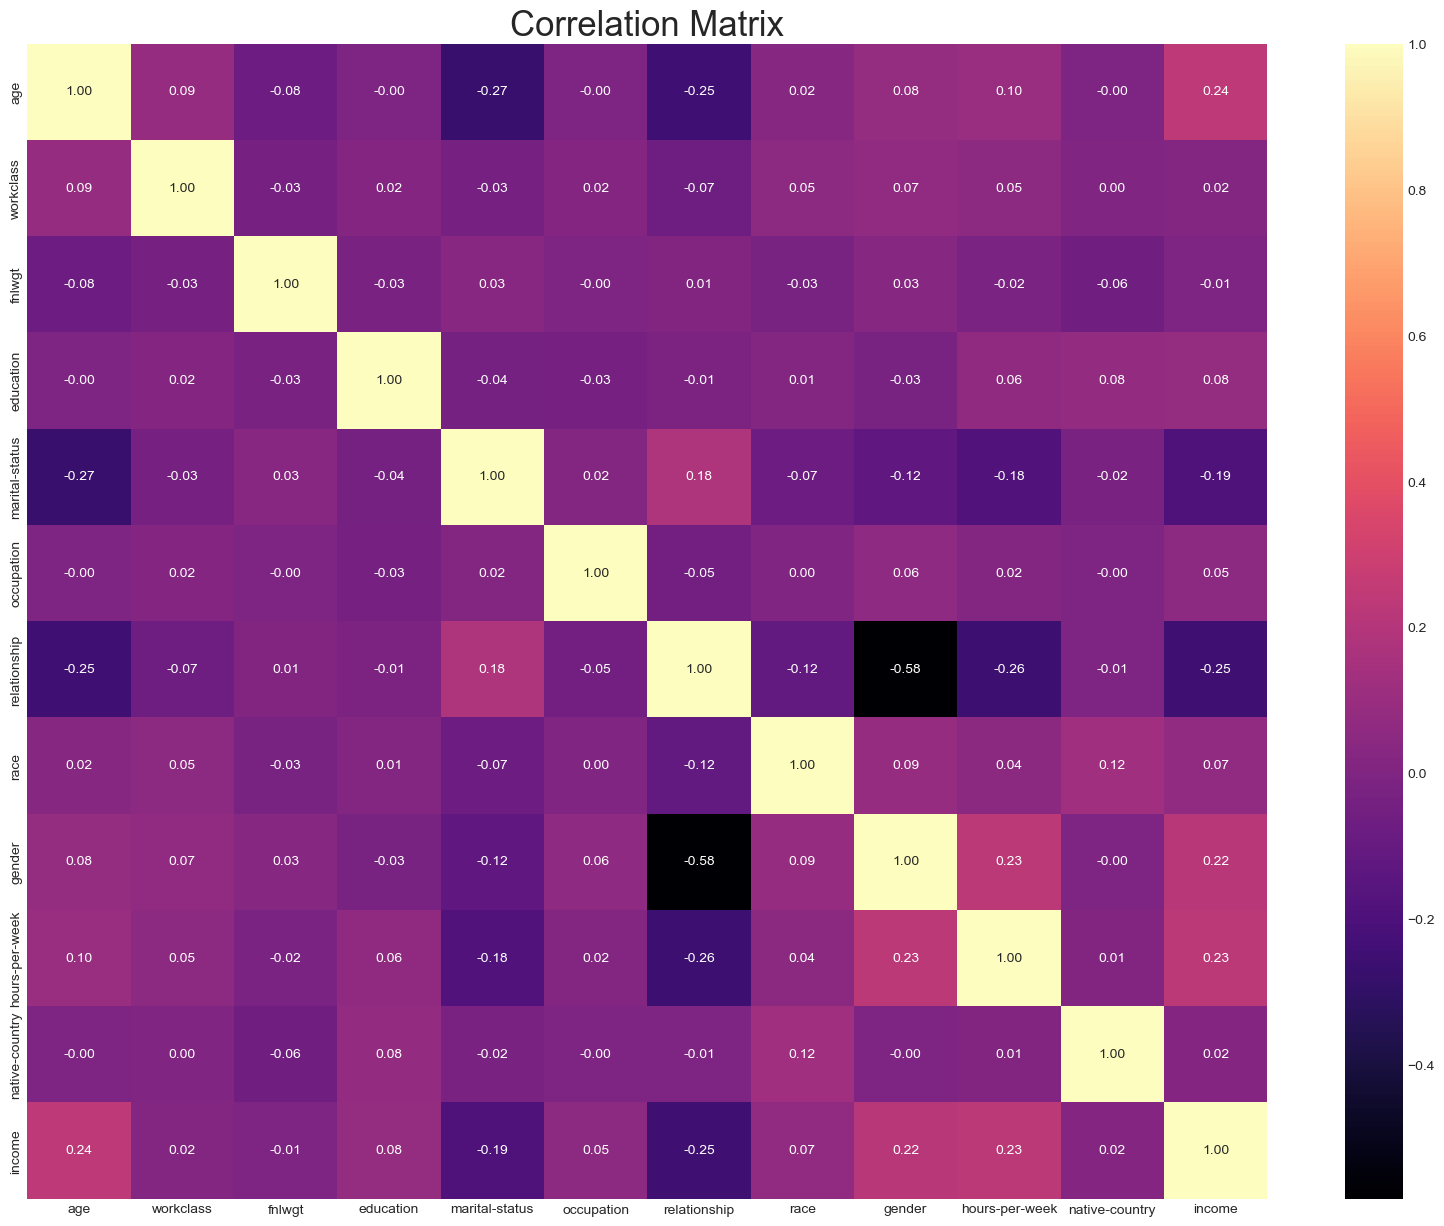

In [34]:
f, ax = plt.subplots(figsize=[20, 15])
sns.heatmap(income_2.corr(), annot=True, fmt=".2f", ax=ax, cmap="magma")
ax.set_title("Correlation Matrix", fontsize=25)

plt.show()

In [35]:
correlation_matrix = income_2.corr()
# Most correlated and least correlated variables with Outcome

# Isolating the 'Outcome' correlation series
correlation = correlation_matrix['income']

# Sorting the correlations to find the top 3 most and least correlated variables
most_corr = correlation.abs().sort_values(ascending=False)[1:4]  
least_corr = correlation.abs().sort_values(ascending=True)[:3]

print("Top 3 most correlated variables with 'income':")
print(most_corr)

print("\nTop 3 least correlated variables with 'income':")
print(least_corr)


Top 3 most correlated variables with 'income':
relationship      0.253362
age               0.236839
hours-per-week    0.227146
Name: income, dtype: float64

Top 3 least correlated variables with 'income':
fnlwgt            0.007227
workclass         0.015644
native-country    0.019855
Name: income, dtype: float64


- `relationship` has the highest correlation with income, accounting for 0.25, followed by `age` and `hours-per-week ` with 0.24 and 0.23 respectively. This means that as relationship increases, there is higher chance the income increase
- `fnlwgt`, `workclass` and `native-country` shows the lowest correlation, indicating that these factors do not significantly affect the `income`

## 4. Splitling data into Training and Tesing for Modelling

### Logistic Regression

In [36]:
# Prepare X and Y for modeling
X = income_2.drop('income',axis=1) #Selecting our predictors
y = income_2['income'] #Selecting our Reponse Variable

In [37]:
#Train Test Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142)

In [38]:
#Scale the data before applying to the model
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [39]:
from sklearn.feature_selection import RFE

# Estimating accuracy score on test by using different number of features
acc_scores = []
for i in range(1,12):
    clf = LogisticRegression()
    rfe = RFE(estimator=clf, n_features_to_select=i)
    # training model
    rfe.fit(X_train, y_train)
    # predicting on test set
    y_pred = rfe.predict(X_test)
    acc_score = accuracy_score(y_test, y_pred)
    # print this
    print("Accuracy on test set using", i, "features: ", round(acc_score,4))
    # append to the list
    acc_scores.append(acc_score)

Accuracy on test set using 1 features:  0.7519
Accuracy on test set using 2 features:  0.7381
Accuracy on test set using 3 features:  0.7475
Accuracy on test set using 4 features:  0.7439
Accuracy on test set using 5 features:  0.749
Accuracy on test set using 6 features:  0.7547
Accuracy on test set using 7 features:  0.755
Accuracy on test set using 8 features:  0.7552
Accuracy on test set using 9 features:  0.7567
Accuracy on test set using 10 features:  0.7553
Accuracy on test set using 11 features:  0.7553


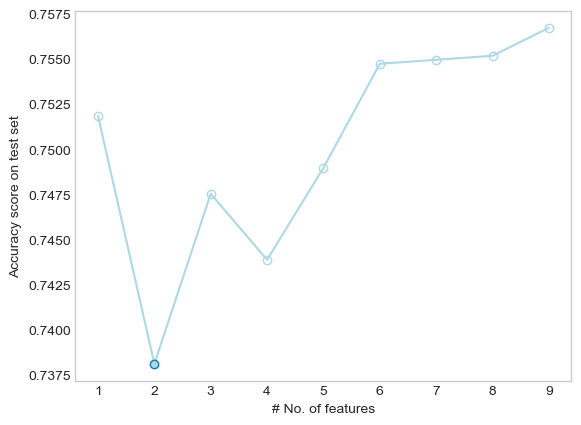

In [40]:
# Estimating accuracy score on test set using RFE by using different number of features
estimator = LogisticRegression()
acc_scores = []
for i in range(1, 10):
    selector = RFE(estimator,n_features_to_select=i)
    selector = selector.fit(X_train, y_train)
    supp = selector.get_support()

    predicted = selector.predict(X_test)
    acc_score = accuracy_score(y_test, predicted)
    acc_scores.append(acc_score)

best = 1
for item in acc_scores:
    if item < acc_scores[best - 1]:
        best = acc_scores.index(item) + 1

plt.grid()
plt.xlabel('# No. of features')
plt.ylabel('Accuracy score on test set')
plt.plot(range(1, 10), acc_scores, marker = 'o', color = 'lightblue', markeredgewidth = 1 ,markeredgecolor = 'lightblue', markerfacecolor = 'None')
plt.plot(best, acc_scores[best-1], marker = 'o', markerfacecolor = 'lightblue')


Selecting 9 features has the highest accuracy 0.7567

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

def evaluate_models(X_train, y_train, X_test, y_test):
    log = LogisticRegression(random_state=0)
    knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski', p=2)
    gauss = GaussianNB()
    tree = DecisionTreeClassifier(criterion="entropy", random_state=0)
    forest = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
    
    models = [log, knn, gauss, tree, forest]
    model_names = ['Logistic Regression', 'K-Nearest Neighbors', 'Gaussian Naive Bayes', 'Decision Tree', 'Random Forest']
    
    accuracies = {}

    # Train and evaluate each model
    for model, name in zip(models, model_names):
        model.fit(X_train, y_train)  # Training model
        y_pred_train = model.predict(X_train)  # Predicting on training set
        y_pred_test = model.predict(X_test)  # Predicting on test set

        train_accuracy = accuracy_score(y_train, y_pred_train)  # Accuracy on training set
        test_accuracy = accuracy_score(y_test, y_pred_test)  # Accuracy on test set

        accuracies[name] = {'Train Accuracy': train_accuracy, 'Test Accuracy': test_accuracy}

        # Print accuracies for each model
        print(f"{name} Training Accuracy: {train_accuracy:.4f}")
        print(f"{name} Testing Accuracy: {test_accuracy:.4f}")
        print("----------------------------")

    return accuracies

model_accuracies = evaluate_models(X_train, y_train, X_test, y_test)


Logistic Regression Training Accuracy: 0.7594
Logistic Regression Testing Accuracy: 0.7553
----------------------------
K-Nearest Neighbors Training Accuracy: 0.8481
K-Nearest Neighbors Testing Accuracy: 0.8028
----------------------------
Gaussian Naive Bayes Training Accuracy: 0.7571
Gaussian Naive Bayes Testing Accuracy: 0.7495
----------------------------
Decision Tree Training Accuracy: 0.9998
Decision Tree Testing Accuracy: 0.7609
----------------------------
Random Forest Training Accuracy: 0.9853
Random Forest Testing Accuracy: 0.8077
----------------------------


- Regarding the testing dataset, Random Forest has the highest accuracy, followed by K-Nearest Neighbors and Decision Tree. 
- All four models exhibit increased accuracy on the training data, indicating indicators of overfitting since there is a significant decrease in testing accuracy.
- Overall, whereas more intricate models such as Random Forest and KNN exhibit greater initial accuracy, they are more susceptible to overfitting when compared to simpler models like Logistic Regression and Naive Bayes.

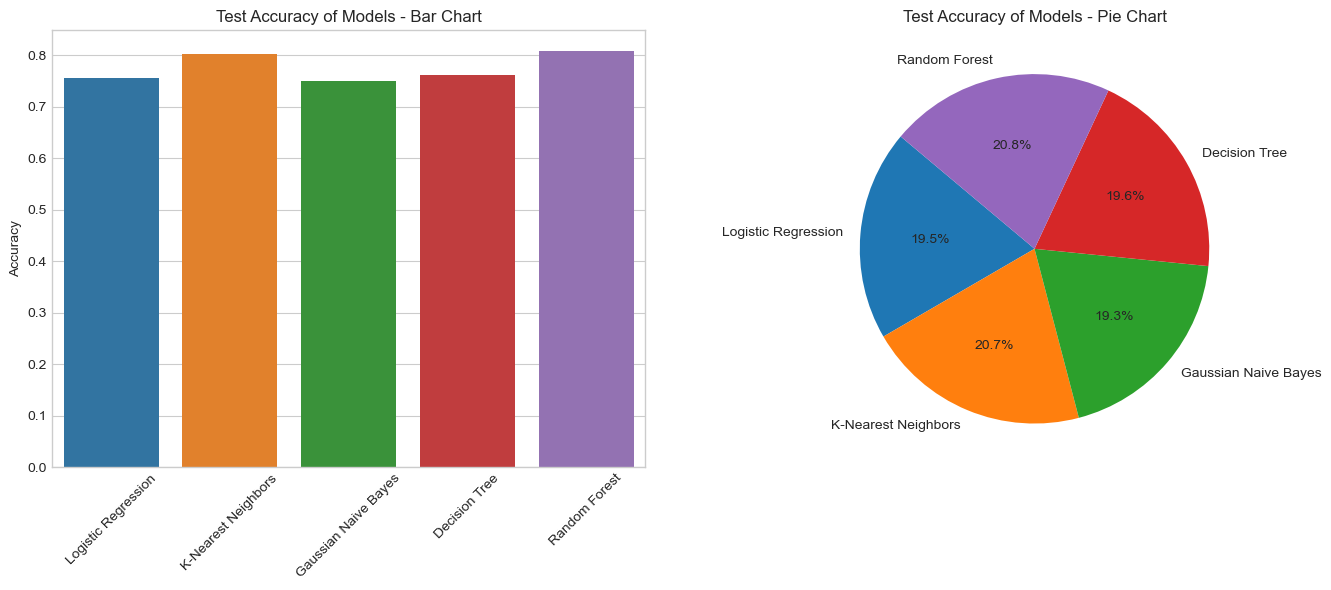

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_accuracies(model_accuracies):
    # Prepare data for plotting
    names = list(model_accuracies.keys())
    test_accuracies = [model_accuracies[name]['Test Accuracy'] for name in names]
    custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'] 

    # Set up the matplotlib figure
    plt.figure(figsize=(14, 6))

    # Bar chart
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
    sns.barplot(x=names, y=test_accuracies, palette=custom_colors)
    plt.title('Test Accuracy of Models - Bar Chart')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)

    # Pie chart
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
    plt.pie(test_accuracies, labels=names, autopct='%1.1f%%', startangle=140, colors=custom_colors)
    plt.title('Test Accuracy of Models - Pie Chart')

    # Display the plots
    plt.tight_layout()
    plt.show()

# model_accuracies = evaluate_models(X_train, y_train, X_test, y_test)
visualize_accuracies(model_accuracies)

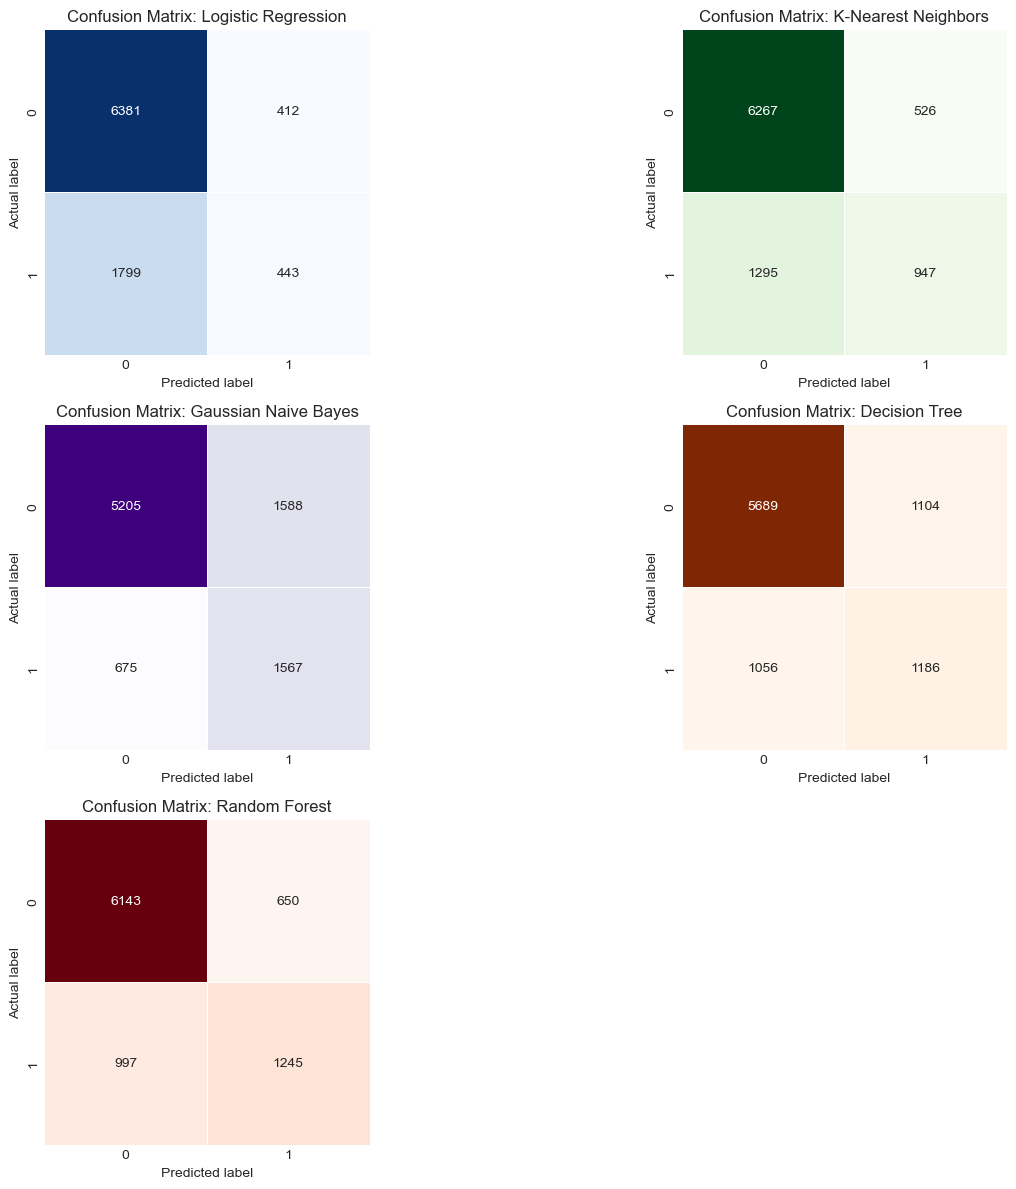

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns  # For visually appealing confusion matrices

def plot_confusion_matrices(X_train, y_train, X_test, y_test):
    # Initialize models
    logistic = LogisticRegression(random_state=0)
    knn = KNeighborsClassifier(n_neighbors=4, metric='minkowski', p=2)
    gaussian = GaussianNB()
    tree = DecisionTreeClassifier(criterion="entropy", random_state=0)
    forest = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=0)  # Random Forest

    # List to store models for ease of iteration
    models = [logistic, knn, gaussian, tree, forest]
    model_names = ['Logistic Regression', 'K-Nearest Neighbors', 'Gaussian Naive Bayes', 'Decision Tree', 'Random Forest']
    colors = ['Blues','Greens', 'Purples','Oranges','Reds']  # Color for Random Forest added

    # Train and predict with each model
    plt.figure(figsize=(14, 12))  # Increased figure size for 5 models
    for idx, (model, name, color) in enumerate(zip(models, model_names, colors), start=1):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        # Subplot for each confusion matrix
        plt.subplot(3, 2, idx)  
        sns.heatmap(cm, annot=True, fmt="d", linewidths=.5, square=True, cmap=color, cbar=False)
        plt.title(f'Confusion Matrix: {name}')
        plt.ylabel('Actual label')
        plt.xlabel('Predicted label')

    plt.tight_layout()  # Adjust subplots to fit into figure area.
    plt.show()


plot_confusion_matrices(X_train, y_train, X_test, y_test)


- Regarding the True Positives, Gaussian Naives Bayes has the highest number with 1567, followed by Random Forest
- With the True Negatives, Logistic Regression has the highest number; however, four models alo do well since the have the high number, accounting for approxiamtely from 5000 to 6000.
- In general, Random Forest and K-Nearest Neighbors algorithms are known for their ability to achieve a good balance between accuracy and error rates. This makes them well-suited for applications that require reliable prediction skills. Gaussian Naive Bayes exhibits a high rate of true positives but also has a significant number of false positives. This makes it appropriate for situations where the failure to identify positives might result in severe outcomes.